In [ ]:
import pandas as pd

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Project_File_50/Final_Data')

In [ ]:
df.shape

(1309, 12)

In [ ]:
df.head()

,Trip,Segment,avg_slope,avg_vehicle_speed,avg_acceleration,avg_total_mass,avg_outdoor_temp,avg_pack_voltage,avg_motor_temperature,SoC_start,SoC_end,total_energy_consumption
0,1,1,2.159000,10.827250,0.216503,1050.0,25.0,49.505500,84.784500,60.030,59.930,15.600
1,1,2,3.398667,13.698930,-0.001634,1050.0,25.0,49.418667,85.023934,59.921,59.850,11.076
2,1,3,1.937857,15.122731,-0.015332,1050.0,25.0,49.430714,85.145164,59.842,59.790,8.112
3,1,4,1.145333,14.286542,-0.034792,1050.0,25.0,49.458667,85.329333,59.781,59.720,9.516
4,1,5,2.927857,15.145690,0.052609,1050.0,25.0,49.419286,85.558571,59.717,59.658,9.204


In [ ]:
df.tail()

,Trip,Segment,avg_slope,avg_vehicle_speed,avg_acceleration,avg_total_mass,avg_outdoor_temp,avg_pack_voltage,avg_motor_temperature,SoC_start,SoC_end,total_energy_consumption
1304,35,34,-2.000000,26.055556,0.216049,700.0,8.83,48.511111,24.0,36.12,36.09,4.68
1305,35,35,-3.250000,26.875000,-0.104167,700.0,8.83,48.862500,24.0,36.09,36.10,-1.56
1306,35,36,-3.500000,26.000000,-0.104167,700.0,8.83,48.975000,24.0,36.09,36.11,-3.12
1307,35,37,-7.090909,19.681818,-0.151515,700.0,8.83,48.954545,24.0,36.11,36.11,0.00
1308,35,38,-6.000000,16.750000,-0.277778,700.0,8.83,49.100000,24.0,36.11,36.11,0.00


In [ ]:
!pip install doWhy

In [ ]:
from dowhy import CausalModel

In [ ]:
model = CausalModel(
    data=df,
    treatment='avg_vehicle_speed',
    outcome='total_energy_consumption',
    common_causes=['avg_slope','avg_total_mass','avg_outdoor_temp']
)

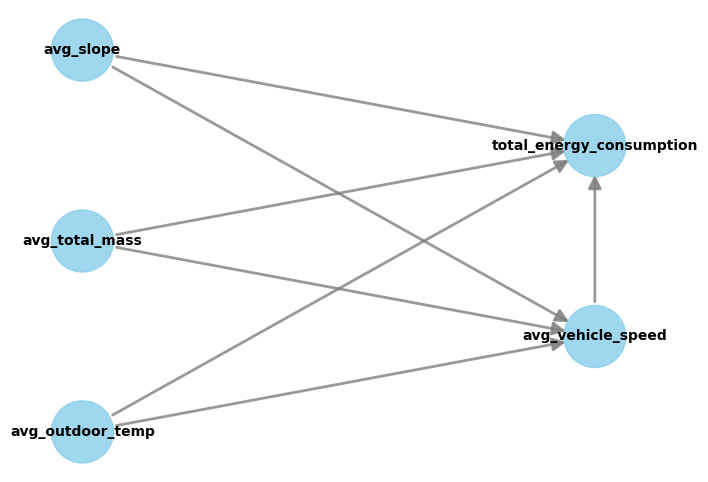

In [ ]:
model.view_model()

In [ ]:
identified_estimand = model.identify_effect()
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
────────────────────(E[total_energy_⟨consumption|⟩_outdoor_⟨temp,⟩_total_⟨mass ↪
d[avg_vehicle_speed]                                                           ↪

↪           
↪ ,⟩_slope])
↪           
Estimand assumption 1, Unconfoundedness: If U→{avg_vehicle_speed} and U→total_energy_consumption then P(total_energy_consumption|avg_vehicle_speed,avg_outdoor_temp,avg_total_mass,avg_slope,U) = P(total_energy_consumption|avg_vehicle_speed,avg_outdoor_temp,avg_total_mass,avg_slope)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                                     ↪
────────────────────(E[total_energy_⟨co

In [ ]:
!pip install econml

In [ ]:
Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

In [ ]:
print(type(T))

<class 'pandas.core.series.Series'>


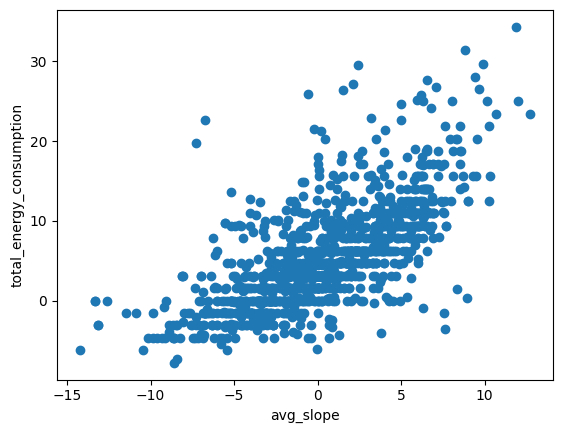

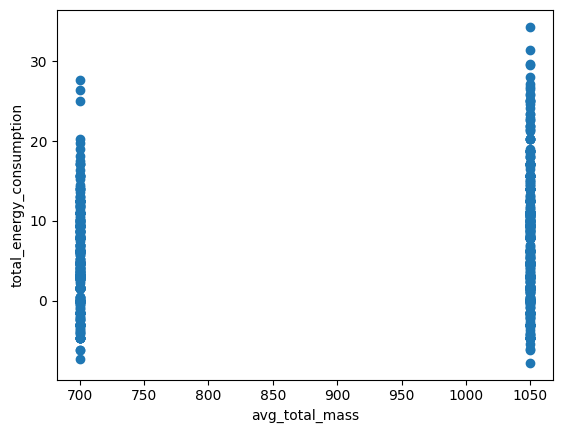

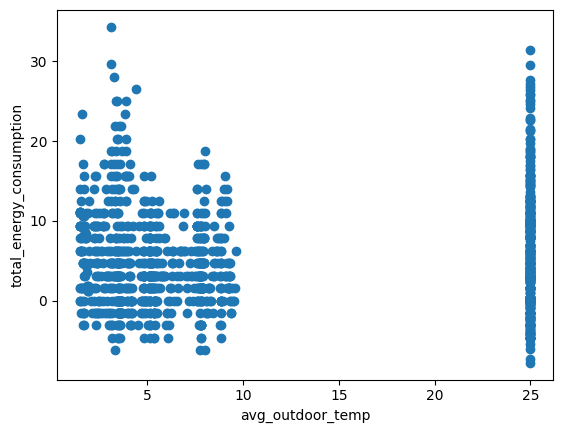

In [ ]:
import matplotlib.pyplot as plt
for col in X.columns:
    plt.scatter(X[col], Y)
    plt.xlabel(col)
    plt.ylabel('total_energy_consumption')
    plt.show()

In [ ]:
from sklearn.model_selection import GroupKFold, GroupShuffleSplit

groups = df["Trip"]

gkf = GroupKFold(n_splits=5)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

Average Treatment Effect (ATE) Estimation:

Treatment Model: Ridge

Outcome Model: Ridge

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import GridSearchCV
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

ridge_y = Ridge()

pipeline_y = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", ridge_y)
])

param_grid_y = {
    'ridge__alpha': [0.1, 1, 10]
}

grid_y = GridSearchCV(
    pipeline_y,
    param_grid=param_grid_y,
    cv=gkf,
    scoring='r2',
    n_jobs=-1
)

grid_y.fit(X, Y, groups=groups)
ridge_best_model_y = grid_y.best_estimator_

print("Best alpha for outcome Ridge:", grid_y.best_params_['ridge__alpha'])

ridge_t = Ridge()

pipeline_t = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", ridge_t)
])

param_grid_t = {
    'ridge__alpha': [0.01, 0.1, 1, 10]
}

grid_t = GridSearchCV(
    pipeline_t,
    param_grid=param_grid_t,
    cv=gkf,
    scoring='r2',
    n_jobs=-1
)

grid_t.fit(X, T, groups=groups)
ridge_best_model_t = grid_t.best_estimator_

print("Best alpha for treatment Ridge:", grid_t.best_params_['ridge__alpha'])

Best alpha for outcome Ridge: 10
Best alpha for treatment Ridge: 10


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd


Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)


train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]
groups_val = groups.iloc[val_idx]

ridge_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in ridge_featurizers.items():

    dml = LinearDML(
        model_y=clone(ridge_best_model_y),
        model_t=clone(ridge_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
2      Poly3  31.891790 -0.001168
1      Poly2  31.481405 -0.017304
0       None  31.162476 -0.041639

Best featurizer: Poly3
Best validation score: 31.89178964096371


In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(ridge_best_model_y),
    model_t=clone(ridge_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

r_ate = final_dml.ate(X_np)
r_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", r_ate)
print("Final Tuned 95% CI:", r_ate_ci)


Final Tuned ATE: -0.05258017812479709
Final Tuned 95% CI: (np.float64(-0.07613951634116037), np.float64(-0.029020839908433817))


In [ ]:
from sklearn.base import clone

ridge_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(ridge_best_model_y),
            "model_t": clone(ridge_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", ridge_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.034241621234014315


Treatment Model: SVR

Outcome Model: SVR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

epsilon_val_y = 0.1
epsilon_val_t = 0.1

svr_y = SVR(kernel="rbf", gamma="scale", epsilon=epsilon_val_y)
pipeline_y = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", svr_y)
])
param_grid_y = {'svr__C': [0.1, 1, 5]}
grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2', n_jobs=-1)
grid_y.fit(X, Y, groups=groups)
svr_best_model_y = grid_y.best_estimator_
print("Best C for outcome SVR:", grid_y.best_params_['svr__C'])

svr_t = SVR(kernel="rbf", gamma="scale", epsilon=epsilon_val_t)
pipeline_t = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", svr_t)
])
param_grid_t = {'svr__C': [0.1, 1, 5]}
grid_t = GridSearchCV(pipeline_t, param_grid=param_grid_t, cv=gkf, scoring='r2', n_jobs=-1)
grid_t.fit(X, T, groups=groups)
svr_best_model_t = grid_t.best_estimator_
print("Best C for treatment SVR:", grid_t.best_params_['svr__C'])

Best C for outcome SVR: 5
Best C for treatment SVR: 5


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

svr_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in svr_featurizers.items():

    dml = LinearDML(
        model_y=clone(svr_best_model_y),
        model_t=clone(svr_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
2      Poly3  32.755789  0.047144
1      Poly2  31.411786  0.021702
0       None  30.363976 -0.009202

Best featurizer: Poly3
Best validation score: 32.75578919392213


In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(svr_best_model_y),
    model_t=clone(svr_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

svr_ate = final_dml.ate(X_np)
svr_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", svr_ate)
print("Final Tuned 95% CI:", svr_ate_ci)


Final Tuned ATE: -0.02505323200604673
Final Tuned 95% CI: (np.float64(-0.048103870665253776), np.float64(-0.002002593346839693))


In [ ]:
from sklearn.base import clone

svr_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(svr_best_model_y),
            "model_t": clone(svr_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", svr_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.010924111845987601


Treatment Model: RFR

Outcome Model: RFR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

rfr_y = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline_y = Pipeline([
    ("scaler", StandardScaler()),
    ("rfr", rfr_y)
])
param_grid_y = {
    'rfr__n_estimators': [100, 200],
    'rfr__max_depth': [3, 5, None],
    'rfr__min_samples_leaf': [1, 5]
}

grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2', n_jobs=-1)
grid_y.fit(X, Y, groups=groups)
rf_best_model_y = grid_y.best_estimator_
print("Best outcome RF params:", grid_y.best_params_)

rfr_t = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline_t = Pipeline([
    ("scaler", StandardScaler()),
    ("rfr", rfr_t)
])
param_grid_t = {
    'rfr__n_estimators': [100, 200],
    'rfr__max_depth': [3, 5, None],
    'rfr__min_samples_leaf': [1, 5]
}
grid_t = GridSearchCV(pipeline_t, param_grid=param_grid_t, cv=gkf, scoring='r2', n_jobs=-1)
grid_t.fit(X, T, groups=groups)
rf_best_model_t = grid_t.best_estimator_
print("Best treatment RF params:", grid_t.best_params_)

Best outcome RF params: {'rfr__max_depth': 5, 'rfr__min_samples_leaf': 5, 'rfr__n_estimators': 100}
Best treatment RF params: {'rfr__max_depth': 3, 'rfr__min_samples_leaf': 1, 'rfr__n_estimators': 200}


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

rf_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in rf_featurizers.items():

    dml = LinearDML(
        model_y=clone(rf_best_model_y),
        model_t=clone(rf_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
1      Poly2  31.617686  0.034306
2      Poly3  31.097316  0.019831
0       None  29.430370 -0.019546

Best featurizer: Poly2
Best validation score: 31.617686197920303


In [ ]:
print(best_featurizer)

PolynomialFeatures(include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(rf_best_model_y),
    model_t=clone(rf_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

rf_ate = final_dml.ate(X_np)
rf_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", rf_ate)
print("Final Tuned 95% CI:", rf_ate_ci)


Final Tuned ATE: -0.07623265269283795
Final Tuned 95% CI: (np.float64(-0.10084987791482619), np.float64(-0.05161542747084972))


In [ ]:
from sklearn.base import clone

rf_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(rf_best_model_y),
            "model_t": clone(rf_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", rf_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.03277462114337128


Treatment Model: GBR

Outcome Model: GBR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

gbr_y = GradientBoostingRegressor(random_state=42)
pipeline_y = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", gbr_y)
])
param_grid_y = {
    'gbr__n_estimators': [100, 200],
    'gbr__max_depth': [3, 5],
    'gbr__learning_rate': [0.05, 0.1],
    'gbr__min_samples_leaf': [1, 5]
}
grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2', n_jobs=-1)
grid_y.fit(X, Y, groups=groups)
gbr_best_model_y = grid_y.best_estimator_
print("Best outcome GBR params:", grid_y.best_params_)

gbr_t = GradientBoostingRegressor(random_state=42)
pipeline_t = Pipeline([
    ("scaler", StandardScaler()),
    ("gbr", gbr_t)
])
param_grid_t = {
    'gbr__n_estimators': [100, 200],
    'gbr__max_depth': [2, 3],
    'gbr__learning_rate': [0.05, 0.1],
    'gbr__min_samples_leaf': [2, 5]
}

grid_t = GridSearchCV(pipeline_t, param_grid=param_grid_t, cv=gkf, scoring='r2', n_jobs=-1)
grid_t.fit(X, T, groups=groups)
gbr_best_model_t = grid_t.best_estimator_
print("Best treatment GBR params:", grid_t.best_params_)

Best outcome GBR params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 3, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 100}
Best treatment GBR params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 2, 'gbr__min_samples_leaf': 2, 'gbr__n_estimators': 100}


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

gbr_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in gbr_featurizers.items():

    dml = LinearDML(
        model_y=clone(gbr_best_model_y),
        model_t=clone(gbr_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
1      Poly2  32.175300  0.022799
2      Poly3  31.922250  0.015776
0       None  30.122337 -0.031355

Best featurizer: Poly2
Best validation score: 32.17529986597394


In [ ]:
print(best_featurizer)

PolynomialFeatures(include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(gbr_best_model_y),
    model_t=clone(gbr_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

gbr_ate = final_dml.ate(X_np)
gbr_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", gbr_ate)
print("Final Tuned 95% CI:", gbr_ate_ci)


Final Tuned ATE: -0.06422179175153328
Final Tuned 95% CI: (np.float64(-0.08946069035810544), np.float64(-0.03898289314496112))


In [ ]:
from sklearn.base import clone

gbr_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(gbr_best_model_y),
            "model_t": clone(gbr_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", gbr_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.028746266994070905


Treatment Model: Ridge

Outcome Model: SVR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import GridSearchCV
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

epsilon_val = 0.1

svr_y = SVR(kernel='rbf', gamma='scale', epsilon=epsilon_val)
pipeline_y = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', svr_y)
])

param_grid_y = {'svr__C': [0.1, 1, 5]}
grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2')
grid_y.fit(X, Y, groups=groups)
svr_r_best_model_y = grid_y.best_estimator_
print("Best SVR outcome C:", grid_y.best_params_['svr__C'])

svr_r_best_model_t =  clone(ridge_best_model_t)

Best SVR outcome C: 5


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

svr_r_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in svr_r_featurizers.items():

    dml = LinearDML(
        model_y=clone(svr_r_best_model_y),
        model_t=clone(svr_r_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
2      Poly3  31.622377  0.016515
1      Poly2  30.860650 -0.000761
0       None  30.198693 -0.023436

Best featurizer: Poly3
Best validation score: 31.62237693643938


In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(svr_r_best_model_y),
    model_t=clone(svr_r_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

svr_r_ate = final_dml.ate(X_np)
svr_r_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", svr_r_ate)
print("Final Tuned 95% CI:", svr_r_ate_ci)


Final Tuned ATE: -0.04997753118891948
Final Tuned 95% CI: (np.float64(-0.07200144164836178), np.float64(-0.0279536207294772))


In [ ]:
from sklearn.base import clone

svr_r_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(svr_r_best_model_y),
            "model_t": clone(svr_r_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)
print("Estimated ATE using DoWhy + LinearDML:", svr_r_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.031108181217558838


Treatment Model: Ridge

Outcome Model: RFR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, LinearRegression
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

rfr_y = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline_y = Pipeline([
    ('scaler', StandardScaler()),
    ('rfr', rfr_y)
])

param_grid_y = {
    'rfr__n_estimators': [100, 200],
    'rfr__max_depth': [3, 5],
    'rfr__min_samples_leaf': [1, 5]
}
grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2', n_jobs=-1)
grid_y.fit(X, Y, groups=groups)
rf_r_best_model_y = grid_y.best_estimator_
print("Best outcome RF params:", grid_y.best_params_)

rf_r_best_model_t =  clone(ridge_best_model_t)

Best outcome RF params: {'rfr__max_depth': 5, 'rfr__min_samples_leaf': 5, 'rfr__n_estimators': 100}


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

rf_r_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in rf_r_featurizers.items():

    dml = LinearDML(
        model_y=clone(rf_r_best_model_y),
        model_t=clone(rf_r_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
2      Poly3  30.856569  0.015073
1      Poly2  30.360930  0.011705
0       None  29.229320 -0.023567

Best featurizer: Poly3
Best validation score: 30.85656852742147


In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(rf_r_best_model_y),
    model_t=clone(rf_r_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

rf_r_ate = final_dml.ate(X_np)
rf_r_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", rf_r_ate)
print("Final Tuned 95% CI:", rf_r_ate_ci)


Final Tuned ATE: -0.05538956239591613
Final Tuned 95% CI: (np.float64(-0.07764062203138883), np.float64(-0.03313850276044343))


In [ ]:
from sklearn.base import clone

rf_r_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(rf_r_best_model_y),
            "model_t": clone(rf_r_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", rf_r_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.03231830457418892


Treatment Model: Ridge

Outcome Model: GBR

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, LinearRegression
from econml.dml import LinearDML

Y = df['total_energy_consumption']
T = df['avg_vehicle_speed']
X = df[['avg_slope', 'avg_total_mass', 'avg_outdoor_temp']]

gbr_y = GradientBoostingRegressor(random_state=42)
pipeline_y = Pipeline([
    ('scaler', StandardScaler()),
    ('gbr', gbr_y)
])

param_grid_y = {
    'gbr__n_estimators': [100, 200],
    'gbr__max_depth': [3, 5],
    'gbr__learning_rate': [0.05, 0.1],
    'gbr__min_samples_leaf': [1, 5]
}
grid_y = GridSearchCV(pipeline_y, param_grid=param_grid_y, cv=gkf, scoring='r2', n_jobs=-1)
grid_y.fit(X, Y, groups=groups)
gbr_r_best_model_y = grid_y.best_estimator_
print("Best outcome GBR params:", grid_y.best_params_)

gbr_r_best_model_t =  clone(ridge_best_model_t)

Best outcome GBR params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 3, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 100}


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.base import clone
from econml.dml import LinearDML
import numpy as np
import pandas as pd

Y_np = np.asarray(Y).ravel()
T_np = np.asarray(T).reshape(-1, 1)
X_np = np.asarray(X)

train_idx, val_idx = next(gss.split(X_np, Y_np, groups=groups))

X_train, X_val = X_np[train_idx], X_np[val_idx]
T_train, T_val = T_np[train_idx], T_np[val_idx]
Y_train, Y_val = Y_np[train_idx], Y_np[val_idx]

groups_train = groups.iloc[train_idx]

gbr_r_featurizers = {
    "None": None,
    "Poly2": PolynomialFeatures(degree=2, include_bias=False),
    "Poly3": PolynomialFeatures(degree=3, include_bias=False)
}

results = []
best_score = -np.inf
best_name = None
best_featurizer = None

for name, feat in gbr_r_featurizers.items():

    dml = LinearDML(
        model_y=clone(gbr_r_best_model_y),
        model_t=clone(gbr_r_best_model_t),
        featurizer=feat,
        cv=gkf,
        random_state=42
    )

    dml.fit(Y_train, T_train, X=X_train, groups=groups_train)

    score = dml.score(Y_val, T_val, X=X_val)
    ate_val = dml.ate(X_val)

    results.append({
        "featurizer": name,
        "val_score": score,
        "ate_val": ate_val
    })

    if score > best_score:
        best_score = score
        best_name = name
        best_featurizer = feat

results_df = pd.DataFrame(results).sort_values("val_score", ascending=False)

print("\nTuning Results:")
print(results_df)

print("\nBest featurizer:", best_name)
print("Best validation score:", best_score)


Tuning Results:
  featurizer  val_score   ate_val
2      Poly3  31.942811  0.025531
1      Poly2  31.011902  0.003964
0       None  29.904383 -0.032025

Best featurizer: Poly3
Best validation score: 31.94281063685519


In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
final_dml = LinearDML(
    model_y=clone(gbr_r_best_model_y),
    model_t=clone(gbr_r_best_model_t),
    featurizer=best_featurizer,
    cv=gkf,
    random_state=42
)

final_dml.fit(Y_np, T_np, X=X_np, groups=groups)

gbr_r_ate = final_dml.ate(X_np)
gbr_r_ate_ci = final_dml.ate_interval(X_np)

print("\nFinal Tuned ATE:", gbr_r_ate)
print("Final Tuned 95% CI:", gbr_r_ate_ci)


Final Tuned ATE: -0.05084538165187092
Final Tuned 95% CI: (np.float64(-0.07391729658238526), np.float64(-0.027773466721356593))


In [ ]:
from sklearn.base import clone

gbr_r_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.LinearDML",
    method_params={
        "init_params": {
            "model_y": clone(gbr_r_best_model_y),
            "model_t": clone(gbr_r_best_model_t),
            "featurizer": best_featurizer,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("Estimated ATE using DoWhy + LinearDML:", gbr_r_estimate.value)

Estimated ATE using DoWhy + LinearDML: -0.030107571962191517


In [ ]:
ate_linear = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
ate_dml = ridge_estimate.value
print("Linear ATE:", ate_linear.value)
print("DML ATE   :", ate_dml)

Linear ATE: -0.04324615384028796
DML ATE   : -0.034241621234014315


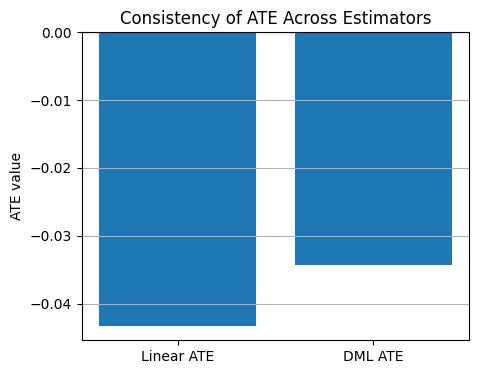

In [ ]:
import matplotlib.pyplot as plt

ate_dml = ridge_estimate.value
plt.figure(figsize=(5,4))
plt.bar(
    ["Linear ATE", "DML ATE"],
    [ate_linear.value, ate_dml]
)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("ATE value")
plt.title("Consistency of ATE Across Estimators")
plt.grid(axis="y")
plt.show()

KDE plots for the Teatment Variable and Selected Confounders:

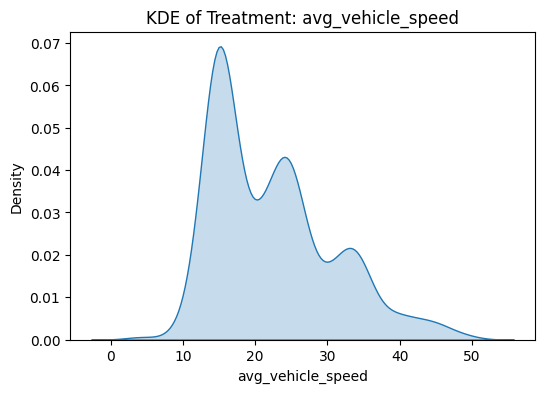

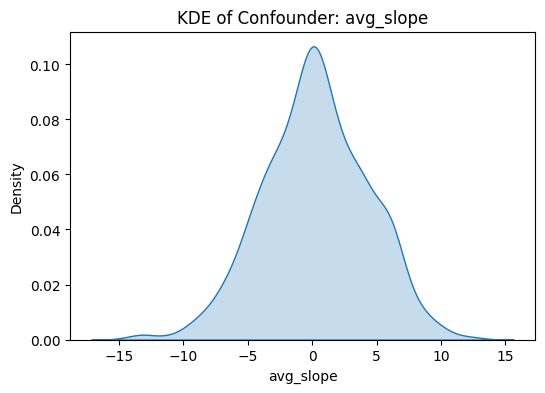

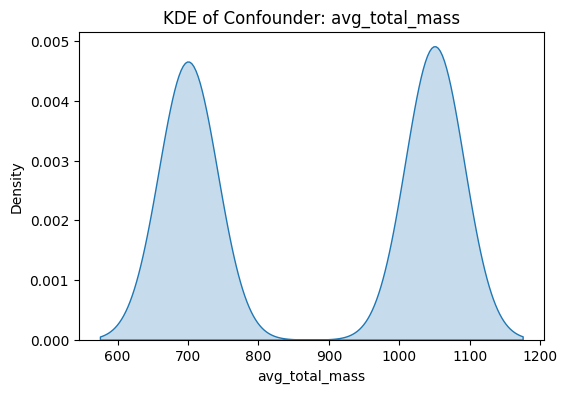

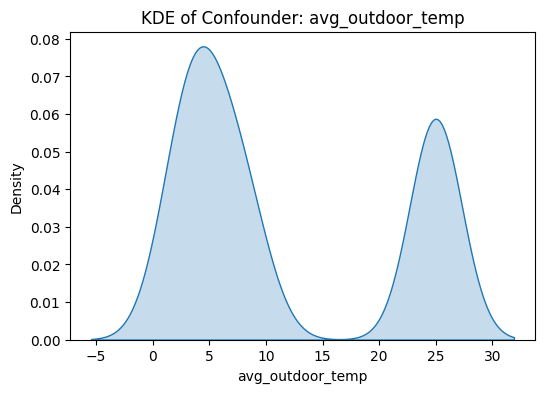

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

treatment = "avg_vehicle_speed"
confounders = ["avg_slope", "avg_total_mass", "avg_outdoor_temp"]

# KDE for Treatment
plt.figure(figsize=(6,4))
sns.kdeplot(df[treatment], fill=True)
plt.title(f"KDE of Treatment: {treatment}")
plt.show()

# KDE for each confounder
for col in confounders:
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE of Confounder: {col}")
    plt.show()

Causal Validation and Robustness Analysis of ATE Estimates:

In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
ate_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.econml.dml.DML",
    method_params={
        "init_params": {
            "model_y": clone(ridge_best_model_y),
            "model_t": clone(ridge_best_model_t),
            "featurizer": best_featurizer,
            "model_final": LinearRegression(),
            "discrete_treatment": False,
            "cv": gkf,
            "random_state": 42
        },
        "fit_params": {"groups": groups}
    }
)

print("ATE:", ate_estimate.value)

ATE: -0.03440976246005578


In [ ]:
# Placebo treatment
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate=ate_estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    method_params={"groups": groups}
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:-0.03440976246005578
New effect:-9.812438151208188e-05
p value:0.92



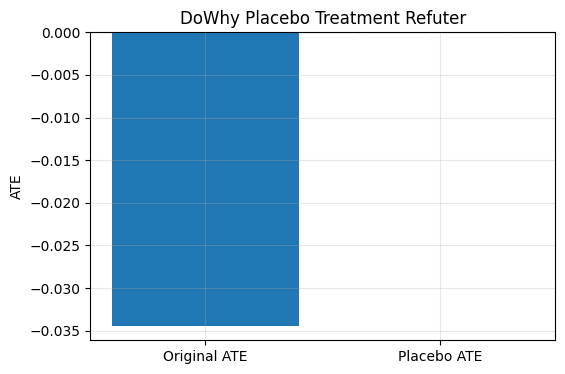

In [ ]:
import matplotlib.pyplot as plt

orig = float(refute_placebo.estimated_effect)
placebo = float(refute_placebo.new_effect)

plt.figure(figsize=(6,4))
plt.bar(["Original ATE", "Placebo ATE"], [orig, placebo])
plt.axhline(0, linestyle="--")
plt.ylabel("ATE")
plt.title("DoWhy Placebo Treatment Refuter")
plt.grid(True, alpha=0.3)
plt.show()

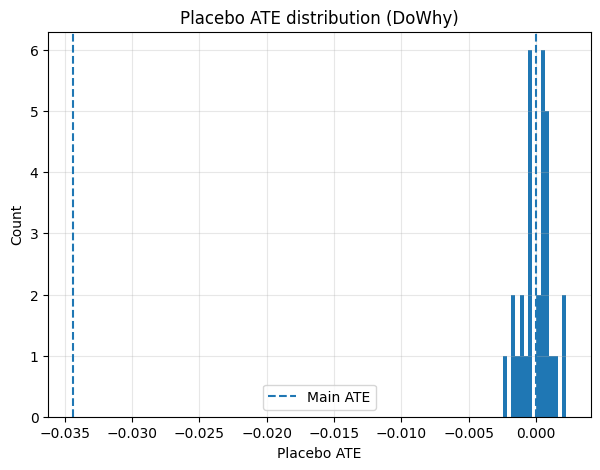

In [ ]:
placebo_vals = []

for _ in range(30):
    r = model.refute_estimate(
        identified_estimand,
        estimate=ate_estimate,
        method_name="placebo_treatment_refuter",
        placebo_type="permute",
        method_params={"groups": groups}
    )
    placebo_vals.append(float(r.new_effect))

plt.figure(figsize=(7,5))
plt.hist(placebo_vals, bins=15)
plt.axvline(0, linestyle="--")
plt.axvline(float(ate_estimate.value), linestyle="--", label="Main ATE")
plt.title("Placebo ATE distribution (DoWhy)")
plt.xlabel("Placebo ATE")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
print(best_featurizer)

PolynomialFeatures(degree=3, include_bias=False)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from econml.dml import LinearDML

def subset_refuter(Y, T, X, groups, model_y, model_t, featurizer, fraction=0.8):

    unique_groups = np.unique(groups)
    selected_groups = np.random.choice(
        unique_groups,
        size=int(len(unique_groups) * fraction),
        replace=False
    )

    mask = np.isin(groups, selected_groups)

    Y_sub, T_sub, X_sub = Y[mask], T[mask], X[mask]

    dml = LinearDML(
        model_y=clone(model_y),
        model_t=clone(model_t),
        featurizer=featurizer,
        random_state=42
    )

    dml.fit(Y_sub, T_sub, X=X_sub)

    return dml.ate(X)

In [ ]:
subset_ates = [
    subset_refuter(
        Y, T, X, groups,
        ridge_best_model_y,
        ridge_best_model_t,
        best_featurizer,
        fraction=0.8
    )
    for _ in range(30)
]

subset_ates = np.array(subset_ates)

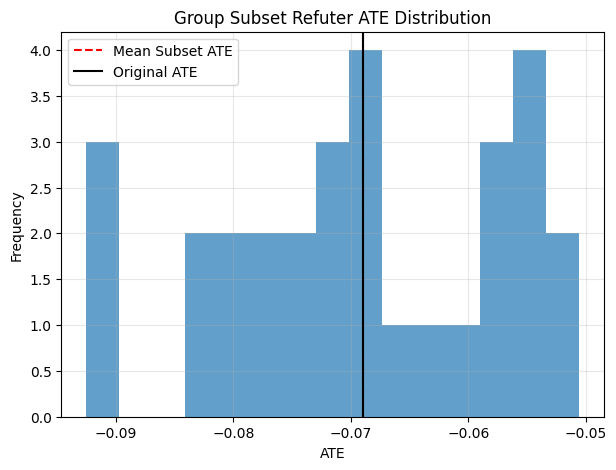

In [ ]:
plt.figure(figsize=(7,5))
plt.hist(subset_ates, bins=15, alpha=0.7)

plt.axvline(np.mean(subset_ates), color='red', linestyle='--', label='Mean Subset ATE')
plt.axvline(np.mean(subset_ates), color='black', linestyle='-', label='Original ATE')

plt.title("Group Subset Refuter ATE Distribution")
plt.xlabel("ATE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

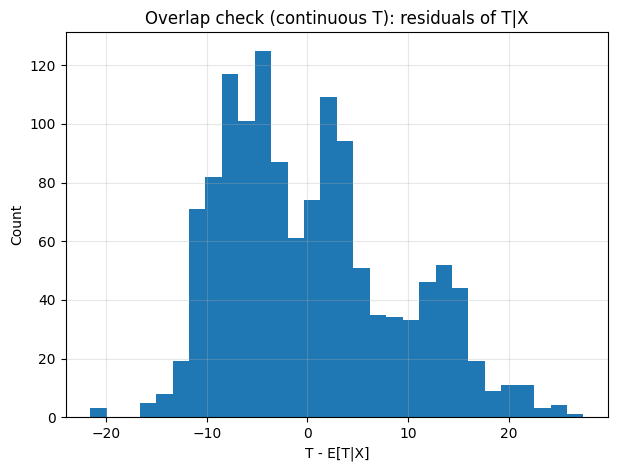

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

T = df["avg_vehicle_speed"].values
X = df[["avg_slope", "avg_total_mass", "avg_outdoor_temp"]].values

t_model = t_model = clone(ridge_best_model_t)

t_hat = cross_val_predict(t_model, X, T, cv=gkf, groups=groups)
residuals = T - t_hat

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.title("Overlap check (continuous T): residuals of T|X")
plt.xlabel("T - E[T|X]")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

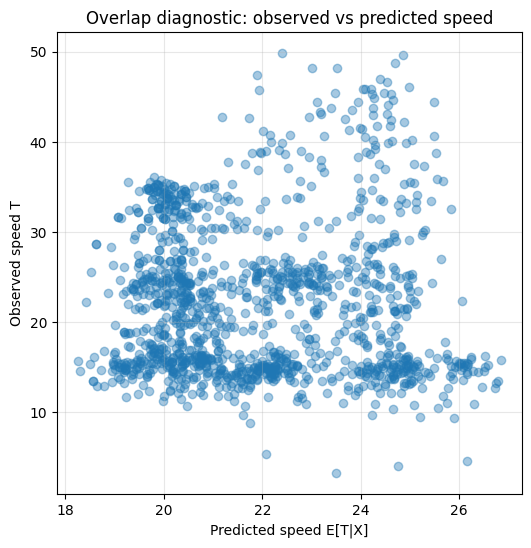

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(t_hat, T, alpha=0.4)
plt.xlabel("Predicted speed E[T|X]")
plt.ylabel("Observed speed T")
plt.title("Overlap diagnostic: observed vs predicted speed")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from econml.dml import LinearDML
from scipy.stats import spearmanr

alphas = [0.1, 1.0, 10.0]
cates = {}

for a in alphas:

    model_t = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])

    dml = LinearDML(
        model_y=clone(ridge_best_model_y),
        model_t=model_t,
        random_state=42
    )

    dml.fit(
        Y=Y,
        T=T,
        X=X,
        groups=groups
    )

    cates[a] = dml.effect(X).ravel()

rho_01_1, _ = spearmanr(cates[0.1], cates[1.0])
rho_1_10, _ = spearmanr(cates[1.0], cates[10.0])

print("Ridge stability (0.1 vs 1):", rho_01_1)
print("Ridge stability (1 vs 10):", rho_1_10)

Ridge stability (0.1 vs 1): 0.9999999357986933
Ridge stability (1 vs 10): 0.999999106531815


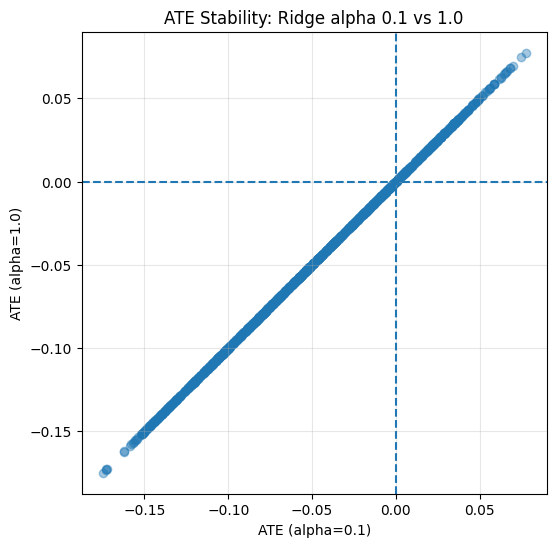

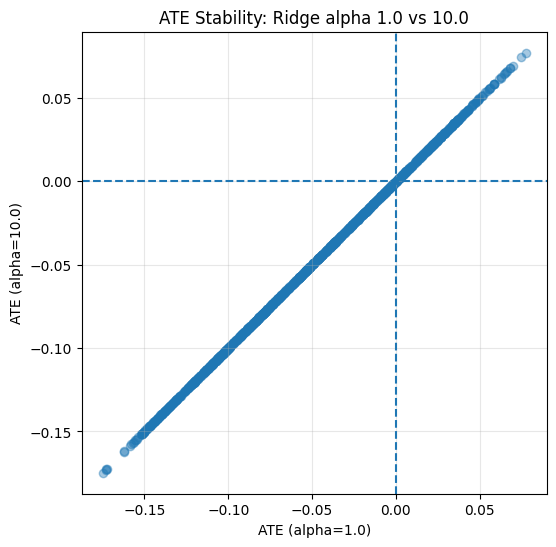

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(cates[0.1], cates[1.0], alpha=0.4)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("ATE (alpha=0.1)")
plt.ylabel("ATE (alpha=1.0)")
plt.title("ATE Stability: Ridge alpha 0.1 vs 1.0")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(cates[1.0], cates[10.0], alpha=0.4)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("ATE (alpha=1.0)")
plt.ylabel("ATE (alpha=10.0)")
plt.title("ATE Stability: Ridge alpha 1.0 vs 10.0")
plt.grid(True, alpha=0.3)
plt.show()

Comparison of ATE Estimates Across Methods:

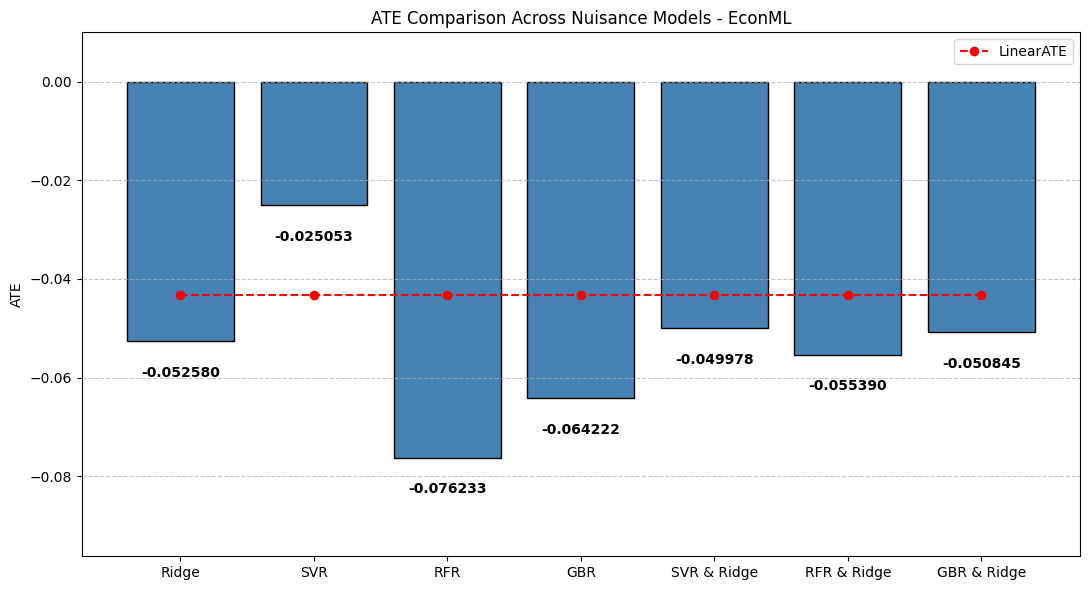

In [ ]:
#LinearDML and EconML
import matplotlib.pyplot as plt

models = ["Ridge", "SVR", "RFR", "GBR", "SVR & Ridge", "RFR & Ridge", "GBR & Ridge"]

dml_ate = [
-0.05258017812479709,
-0.02505323200604673,
-0.07623265269283795,
-0.06422179175153328,
-0.04997753118891948,
-0.05538956239591613,
-0.05084538165187092
]


# Linear ATE
linear_ate = [-0.04324615384028796]*7

plt.figure(figsize=(11,6))
bars = plt.bar(models, dml_ate, color='steelblue', edgecolor='black')

plt.plot(range(len(models)), linear_ate, color='red', marker='o', linestyle='--', label='LinearATE')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 0.005,
        f"{dml_ate[i]:.6f}",
        ha='center', va='top', color='black', fontweight='bold'
    )

plt.ylabel("ATE")
plt.title("ATE Comparison Across Nuisance Models - EconML")
plt.ylim(min(dml_ate)-0.02, 0.01)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


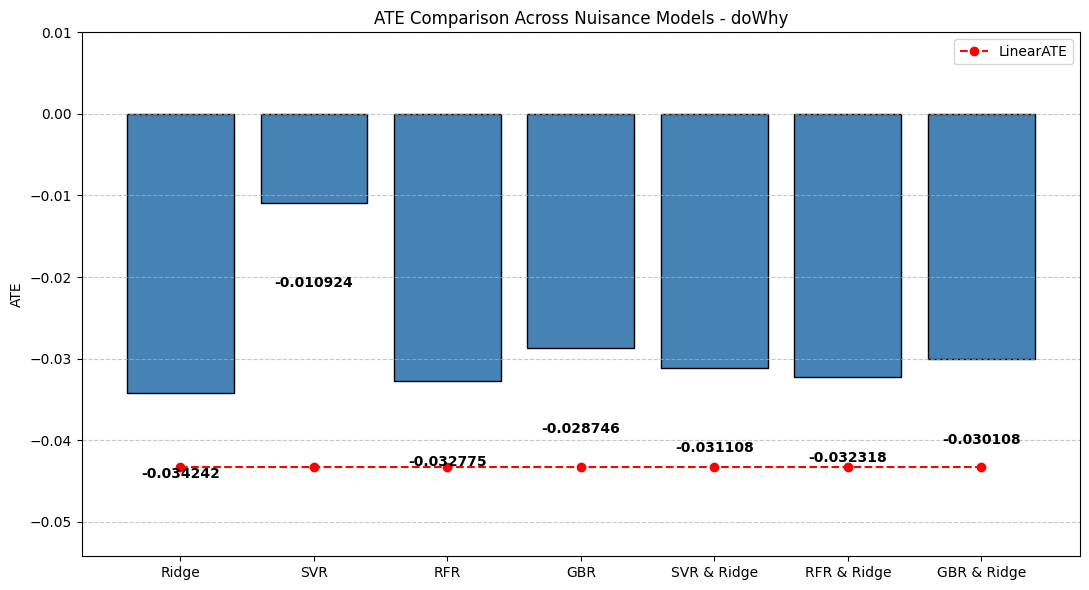

In [ ]:
#Using doWhy
import matplotlib.pyplot as plt

models = ["Ridge", "SVR", "RFR", "GBR", "SVR & Ridge", "RFR & Ridge", "GBR & Ridge"]

dml_ate = [
-0.034241621234014315,
-0.010924111845987601,
-0.03277462114337128,
-0.028746266994070905,
-0.031108181217558838,
-0.03231830457418892,
-0.030107571962191517
]

# Linear ATE
linear_ate = [-0.04324615384028796]*7

plt.figure(figsize=(11,6))
bars = plt.bar(models, dml_ate, color='steelblue', edgecolor='black')

plt.plot(range(len(models)), linear_ate, color='red', marker='o', linestyle='--', label='LinearATE')

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height - 0.009,
        f"{dml_ate[i]:.6f}",
        ha='center', va='top', color='black', fontweight='bold'
    )

plt.ylabel("ATE")
plt.title("ATE Comparison Across Nuisance Models - doWhy")
plt.ylim(min(dml_ate)-0.02, 0.01)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

       Model  LinearDML_ATE  CI_Lower  CI_Upper  DoWhy_ATE
0      Ridge      -0.052580 -0.076140 -0.029021  -0.034242
1        SVR      -0.025053 -0.048104 -0.002003  -0.010924
2        RFR      -0.076233 -0.100850 -0.051615  -0.032775
3        GBR      -0.064222 -0.089461 -0.038983  -0.028746
4  SVR+Ridge      -0.049978 -0.072001 -0.027954  -0.031108
5  RFR+Ridge      -0.055390 -0.077641 -0.033139  -0.032318
6  GBR+Ridge      -0.050845 -0.073917 -0.027773  -0.030108


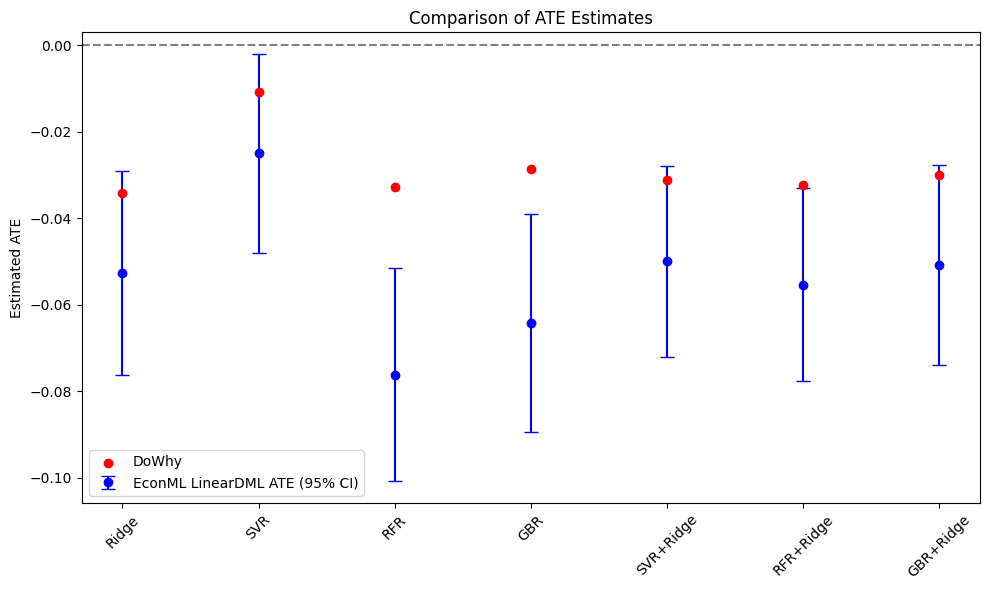

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = [
    "Ridge", "SVR", "RFR", "GBR",
    "SVR+Ridge", "RFR+Ridge", "GBR+Ridge"
]

# LinearDML
ate_ml = [
-0.05258017812479709,
-0.02505323200604673,
-0.07623265269283795,
-0.06422179175153328,
-0.04997753118891948,
-0.05538956239591613,
-0.05084538165187092
]

# LinearDML 95% CI
ci_lower = [-0.07613951634116037,-0.048103870665253776,-0.10084987791482619,-0.08946069035810544,-0.07200144164836178,-0.07764062203138883,-0.07391729658238526]
ci_upper = [-0.029020839908433817,-0.002002593346839693,-0.05161542747084972,-0.03898289314496112,-0.0279536207294772,-0.03313850276044343,-0.027773466721356593]

# DoWhy
ate_dowhy = [
-0.034241621234014315,
-0.010924111845987601,
-0.03277462114337128,
-0.028746266994070905,
-0.031108181217558838,
-0.03231830457418892,
-0.030107571962191517
]

df_results = pd.DataFrame({
    "Model": models,
    "LinearDML_ATE": ate_ml,
    "CI_Lower": ci_lower,
    "CI_Upper": ci_upper,
    "DoWhy_ATE": ate_dowhy
})

print(df_results)

plt.figure(figsize=(10,6))

plt.errorbar(
    x=models,
    y=ate_ml,
    yerr=[np.array(ate_ml)-np.array(ci_lower), np.array(ci_upper)-np.array(ate_ml)],
    fmt='o',
    capsize=5,
    label='EconML LinearDML ATE (95% CI)',
    color='blue'
)

plt.scatter(
    models,
    ate_dowhy,
    color='red',
    label='DoWhy',
    zorder=5
)

plt.axhline(0, color='gray', linestyle='--')
plt.ylabel("Estimated ATE")
plt.title("Comparison of ATE Estimates")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Counterfactual Predictions using ATE:

In [ ]:
baseline_speed = df['avg_vehicle_speed'].mean()
baseline_energy = df['total_energy_consumption'].mean()

In [ ]:
ATE = ridge_estimate.value

In [ ]:
ATE

np.float64(-0.034241621234014315)

In [ ]:
import numpy as np

speed_vals = np.array([10, 20, 30, 40, 50])

cf_energy = baseline_energy + ATE * (speed_vals - baseline_speed)

for s, e in zip(speed_vals, cf_energy):
    print(f"Speed={s} - Counterfactual Energy = {e:.4f}")

Speed=10 - Counterfactual Energy = 5.5784
Speed=20 - Counterfactual Energy = 5.2359
Speed=30 - Counterfactual Energy = 4.8935
Speed=40 - Counterfactual Energy = 4.5511
Speed=50 - Counterfactual Energy = 4.2087


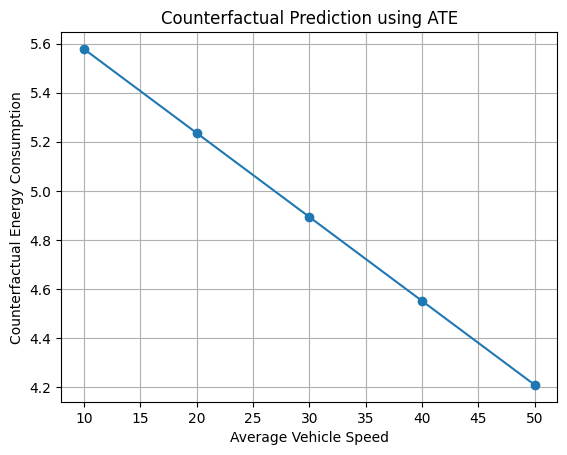

In [ ]:
import matplotlib.pyplot as plt

plt.plot(speed_vals, cf_energy, marker='o')
plt.xlabel("Average Vehicle Speed")
plt.ylabel("Counterfactual Energy Consumption")
plt.title("Counterfactual Prediction using ATE")
plt.grid(True)
plt.show()

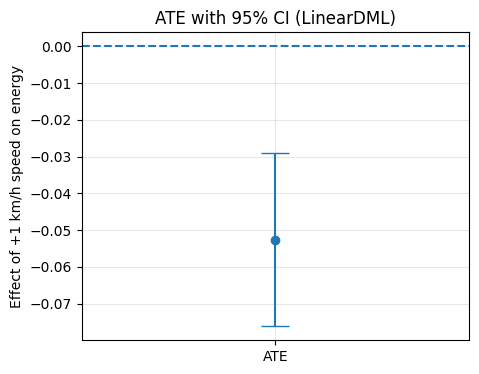

ATE: -0.052580
95% CI: [-0.076140, -0.029021]


In [ ]:
from econml.dml import LinearDML
import matplotlib.pyplot as plt

ate = r_ate
low, high = r_ate_ci

plt.figure(figsize=(5,4))
plt.errorbar(
    x=[0],
    y=[ate],
    yerr=[[ate - low], [high - ate]],
    fmt="o",
    capsize=10
)
plt.xticks([0], ["ATE"])
plt.axhline(0, linestyle="--")
plt.ylabel("Effect of +1 km/h speed on energy")
plt.title("ATE with 95% CI (LinearDML)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"ATE: {ate:.6f}")
print(f"95% CI: [{low:.6f}, {high:.6f}]")

Conditional Average Treatment Effect (CATE) Estimation:

In [ ]:
import numpy as np
from econml.dml import LinearDML
from sklearn.linear_model import Ridge

In [ ]:
# Outcome
Y = df['total_energy_consumption'].values

# Treatment
T = df[['avg_vehicle_speed']].values

# Confounders
X = df[['avg_slope', 'avg_total_mass','avg_outdoor_temp']].values

In [ ]:
print(ridge_best_model_y)
print(ridge_best_model_t)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=10))])
Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=10))])


In [ ]:
linear_dml = LinearDML(
    model_y=clone(ridge_best_model_y),
    model_t=clone(ridge_best_model_t),
    featurizer=PolynomialFeatures(degree=3, include_bias=False),
    cv=gkf,
    random_state=42
)

linear_dml.fit(
    Y=Y,
    T=T,
    X=X,
    groups=groups
)

In [ ]:
def query_cate(linear_dml, conditions, delta_speed=1):

    X_query = np.array(conditions)
    cate_ldml = linear_dml.effect(X_query).ravel()
    energy_change = cate_ldml * delta_speed

    return energy_change

In [ ]:
def compute_cate_with_speed_change(linear_dml, slope, mass, outdoor_temp, delta_speeds=[1]):

    X_input = np.array([[slope, mass, outdoor_temp]])
    cate_ldml = linear_dml.effect(X_input)[0]

    lower, upper = linear_dml.effect_interval(X_input)
    ci_lower = lower[0]
    ci_upper = upper[0]

    results = []

    for ds in delta_speeds:
        energy_change = cate_ldml * ds

        ci_l = ci_lower * ds
        ci_u = ci_upper * ds

        ci_l, ci_u = min(ci_l, ci_u), max(ci_l, ci_u)

        results.append({
            "Slope": slope,
            "Mass": mass,
            "Outdoor Temp": outdoor_temp,
            "Delta Speed": ds,
            "CATE (+1 km/h)": cate_ldml,
            "Energy Change": energy_change,
            "95% CI Lower": ci_l,
            "95% CI Upper": ci_u
        })

    return results

In [ ]:
conditions = [
    [2.0, 1050, 25.0],
    [5.0, 1050, 25.0],
    [2.0, 1050, 5.0]
]

energy_change_1 = query_cate(linear_dml, conditions, delta_speed=1)

print("\nCATE (+1 km/h):")
for i, val in enumerate(energy_change_1):
    slope, mass, temp = conditions[i]
    print(f"Slope={slope}, Mass={mass}, Temp={temp}°C → {val:.4f} kWh")


CATE (+1 km/h):
Slope=2.0, Mass=1050, Temp=25.0°C → -0.0273 kWh
Slope=5.0, Mass=1050, Temp=25.0°C → 0.0182 kWh
Slope=2.0, Mass=1050, Temp=5.0°C → -0.1109 kWh


In [ ]:
row0 = df.iloc[0]

delta_speeds = [1, 5, 10]

results = compute_cate_with_speed_change(
    linear_dml,
    slope=row0['avg_slope'],
    mass=row0['avg_total_mass'],
    outdoor_temp=row0['avg_outdoor_temp'],
    delta_speeds=delta_speeds
)

print("\nInput-Specific Causal Effect")

for res in results:
    print("\n---")
    for k, v in res.items():
        if isinstance(v, np.number):
            print(f"{k}: {v:.4f}")
        else:
            print(f"{k}: {v}")


Input-Specific Causal Effect

---
Slope: 2.1590
Mass: 1050.0000
Outdoor Temp: 25.0000
Delta Speed: 1
CATE (+1 km/h): -0.0254
Energy Change: -0.0254
95% CI Lower: -0.1259
95% CI Upper: 0.0752

---
Slope: 2.1590
Mass: 1050.0000
Outdoor Temp: 25.0000
Delta Speed: 5
CATE (+1 km/h): -0.0254
Energy Change: -0.1269
95% CI Lower: -0.6296
95% CI Upper: 0.3758

---
Slope: 2.1590
Mass: 1050.0000
Outdoor Temp: 25.0000
Delta Speed: 10
CATE (+1 km/h): -0.0254
Energy Change: -0.2538
95% CI Lower: -1.2592
95% CI Upper: 0.7516


In [ ]:
import joblib
joblib.dump(linear_dml, "/content/drive/MyDrive/Project_File_50/CI_Models/linear_dml_final.pkl")

['/content/drive/MyDrive/Project_File_50/CI_Models/linear_dml_final.pkl']

CATE Visualization and Analysis:

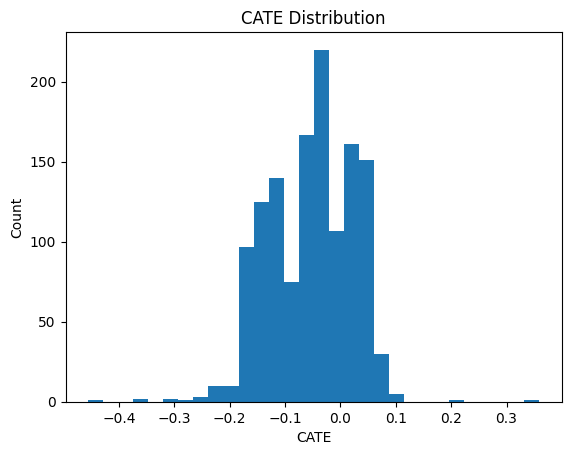

Mean CATE: -0.05258017812479709
Std CATE : 0.07573009491790987
% Positive: 28.72421695951108


In [ ]:
import matplotlib.pyplot as plt

cate_main = linear_dml.effect(X).ravel()

plt.hist(cate_main, bins=30)
plt.xlabel("CATE")
plt.ylabel("Count")
plt.title("CATE Distribution")
plt.show()

print("Mean CATE:", cate_main.mean())
print("Std CATE :", cate_main.std())
print("% Positive:", (cate_main > 0).mean() * 100)

In [ ]:
print(cate_main.min())
print(cate_main.max())

-0.4556378469069562
0.3588975757632038


In [ ]:
cate_main = linear_dml.effect(X).ravel()

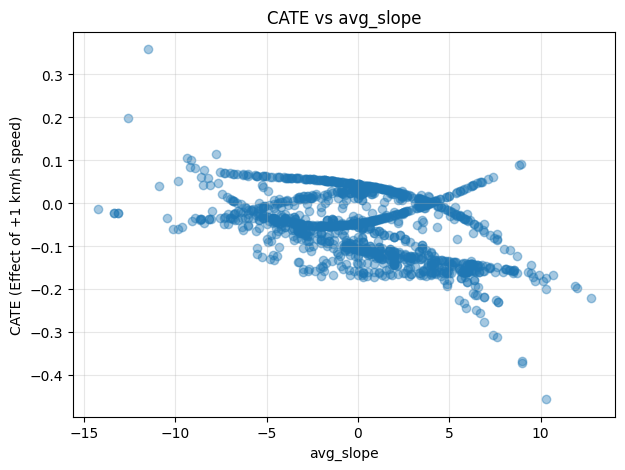

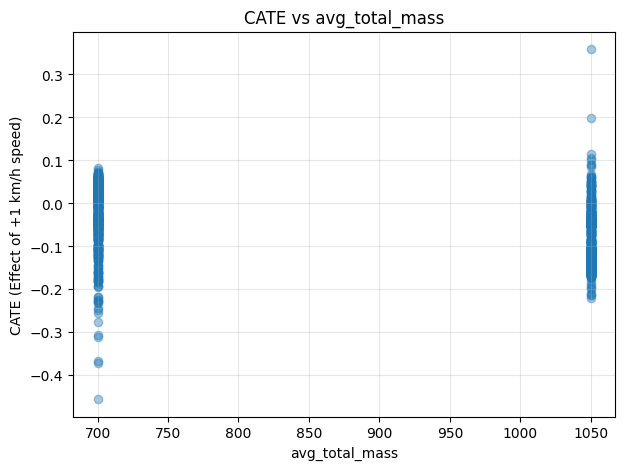

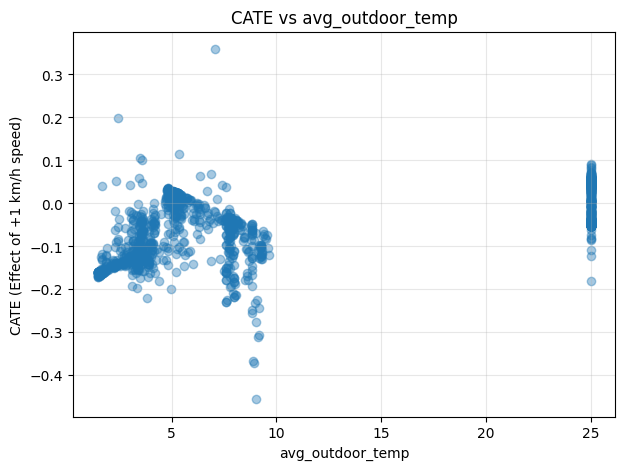

In [ ]:
import matplotlib.pyplot as plt

confounder_names = ["avg_slope", "avg_total_mass", "avg_outdoor_temp"]

for i, name in enumerate(confounder_names):
    plt.figure(figsize=(7,5))
    plt.scatter(df[name].values, cate_main, alpha=0.4)
    plt.xlabel(name)
    plt.ylabel("CATE (Effect of +1 km/h speed)")
    plt.title(f"CATE vs {name}")
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
def plot_counterfactual_outcome_curve(linear_dml, row,
                                      t_min=10, t_max=60, n_points=40):

    X_row = np.array([[row["avg_slope"], row["avg_total_mass"], row["avg_outdoor_temp"]]])
    y_obs = row["total_energy_consumption"]
    t_obs = row["avg_vehicle_speed"]

    t_grid = np.linspace(t_min, t_max, n_points)

    t0 = np.full_like(t_grid, t_obs)
    t1 = t_grid

    effects = linear_dml.effect(X=X_row, T0=t0, T1=t1).ravel()
    y_cf = y_obs + effects

    plt.figure(figsize=(7,5))
    plt.plot(t_grid, y_cf, marker="o")
    plt.axvline(t_obs, linestyle="--", label="Observed speed")
    plt.xlabel("Speed (km/h)")
    plt.ylabel("Counterfactual Energy")
    plt.title("Counterfactual Outcome Curve: Y(do(T=t))")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


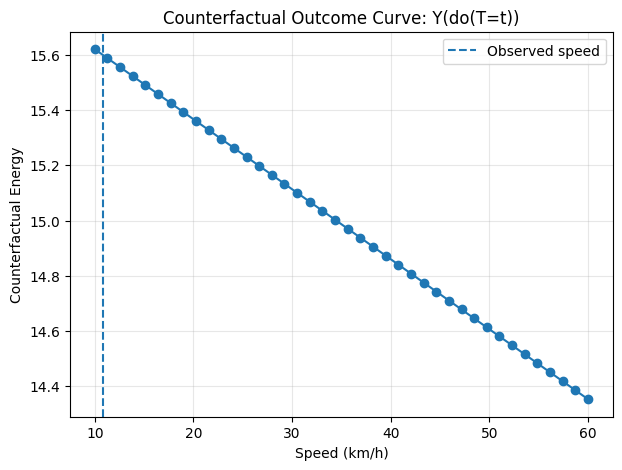

In [ ]:
plot_counterfactual_outcome_curve(linear_dml, df.iloc[0], t_min=10, t_max=60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def ice_pdp_cate_plot(linear_dml, df, X_cols, feature,
                      n_ice=30, grid_points=25, random_state=42):

    rng = np.random.RandomState(random_state)

    X = df[X_cols].values

    feat_idx = X_cols.index(feature)

    x_min, x_max = df[feature].min(), df[feature].max()
    grid = np.linspace(x_min, x_max, grid_points)

    idx = rng.choice(len(df), size=min(n_ice, len(df)), replace=False)

    ice_curves = []

    for i in idx:
        x_base = X[i].copy()

        effects = []
        for g in grid:
            x_new = x_base.copy()
            x_new[feat_idx] = g
            effects.append(linear_dml.effect(np.array([x_new]))[0])

        ice_curves.append(effects)

    ice_curves = np.array(ice_curves)
    pdp = ice_curves.mean(axis=0)

    plt.figure(figsize=(8,5))

    for i in range(ice_curves.shape[0]):
        plt.plot(grid, ice_curves[i], alpha=0.25)

    plt.plot(grid, pdp, linewidth=3, label="PDP (mean ICE)")

    plt.xlabel(feature)
    plt.ylabel("CATE (effect of +1 km/h speed on energy)")
    plt.title(f"ICE + PDP of CATE vs {feature}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

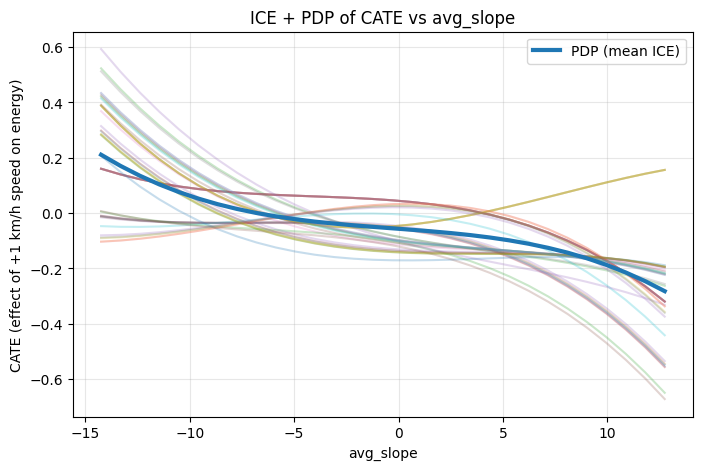

In [ ]:
X_cols = ["avg_slope", "avg_total_mass", "avg_outdoor_temp"]

ice_pdp_cate_plot(
    linear_dml=linear_dml,
    df=df,
    X_cols=X_cols,
    feature="avg_slope",
    n_ice=40,
    grid_points=30
)

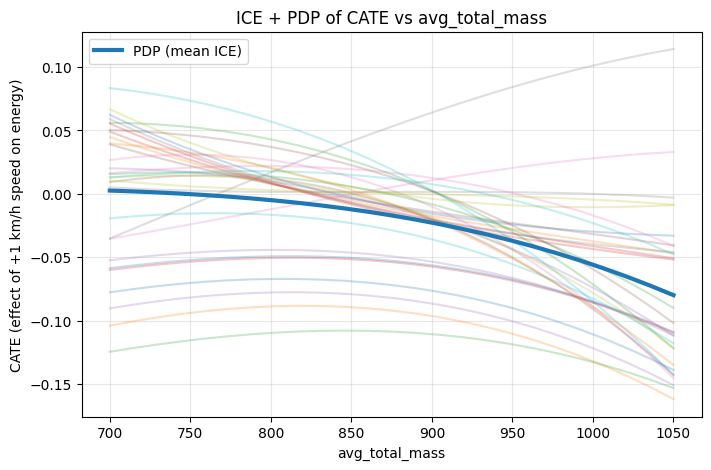

In [ ]:
ice_pdp_cate_plot(linear_dml, df, X_cols, "avg_total_mass")

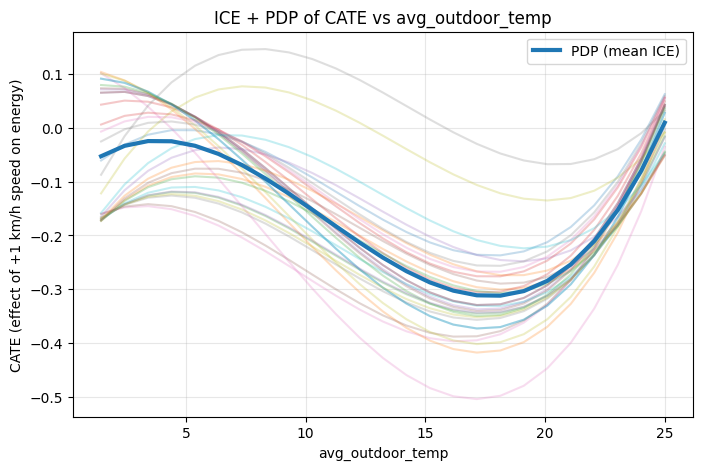

In [ ]:
ice_pdp_cate_plot(linear_dml, df, X_cols, "avg_outdoor_temp")

In [ ]:
print(df['avg_slope'].min())
print(df['avg_slope'].max())

-14.25
12.75


In [ ]:
print(df['avg_total_mass'].min())
print(df['avg_total_mass'].max())

700.0
1050.0


In [ ]:
print(df['avg_outdoor_temp'].min())
print(df['avg_outdoor_temp'].max())

1.4599999999999995
25.0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def cate_uncertainty_continuous_feature(
    linear_dml, df, feature,
    x_cols=("avg_slope", "avg_total_mass", "avg_outdoor_temp"),
    n_bins=10
):
    df_tmp = df[list(x_cols)].copy()
    df_tmp["feature"] = df[feature].values
    df_tmp["bin"] = pd.qcut(df_tmp["feature"], q=n_bins, duplicates="drop")

    centers, cate_means, low_means, high_means = [], [], [], []

    for b, g in df_tmp.groupby("bin"):
        Xg = g[list(x_cols)].values

        cate = linear_dml.effect(Xg).ravel()
        low, high = linear_dml.effect_interval(Xg)

        centers.append(g["feature"].mean())
        cate_means.append(cate.mean())
        low_means.append(low.mean())
        high_means.append(high.mean())

    centers = np.array(centers)
    idx = np.argsort(centers)

    centers = centers[idx]
    cate_means = np.array(cate_means)[idx]
    low_means = np.array(low_means)[idx]
    high_means = np.array(high_means)[idx]

    plt.figure(figsize=(8,5))
    plt.plot(centers, cate_means, marker="o")
    plt.fill_between(centers, low_means, high_means, alpha=0.2)
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("CATE (+1 km/h effect on energy)")
    plt.title(f"CATE uncertainty vs {feature}")
    plt.grid(True, alpha=0.3)
    plt.show()

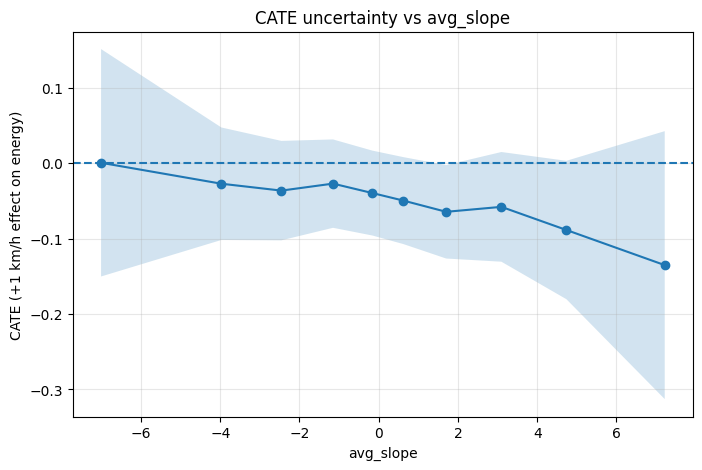

In [ ]:
cate_uncertainty_continuous_feature(linear_dml, df, feature="avg_slope", n_bins=10)

In [ ]:
def cate_uncertainty_mass_two_groups(
    linear_dml, df,
    mass_col="avg_total_mass",
    x_cols=("avg_slope", "avg_total_mass", "avg_outdoor_temp")
):
    masses = sorted(df[mass_col].unique())

    cate_means, low_means, high_means = [], [], []

    for m in masses:
        g = df[df[mass_col] == m]
        Xg = g[list(x_cols)].values

        cate = linear_dml.effect(Xg).ravel()
        low, high = linear_dml.effect_interval(Xg)

        cate_means.append(cate.mean())
        low_means.append(low.mean())
        high_means.append(high.mean())

    cate_means = np.array(cate_means)
    low_means = np.array(low_means)
    high_means = np.array(high_means)

    x = np.arange(len(masses))
    yerr = np.vstack([cate_means - low_means, high_means - cate_means])

    plt.figure(figsize=(6,4))
    plt.errorbar(x, cate_means, yerr=yerr, fmt="o", capsize=6)
    plt.axhline(0, linestyle="--")
    plt.xticks(x, [str(m) for m in masses])
    plt.xlabel("avg_total_mass")
    plt.ylabel("CATE (+1 km/h effect on energy)")
    plt.title("CATE uncertainty by mass group")
    plt.grid(True, alpha=0.3)
    plt.show()

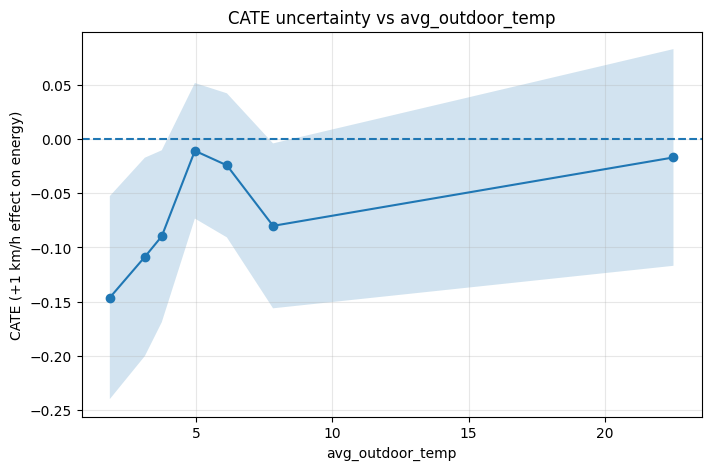

In [ ]:
cate_uncertainty_continuous_feature(linear_dml, df, feature="avg_outdoor_temp", n_bins=10)

In [ ]:
def cate_uncertainty_mass_two_groups(
    linear_dml, df,
    mass_col="avg_total_mass",
    x_cols=("avg_slope", "avg_total_mass", "avg_outdoor_temp")
):
    masses = sorted(df[mass_col].unique())

    cate_means, low_means, high_means = [], [], []

    for m in masses:
        g = df[df[mass_col] == m]
        Xg = g[list(x_cols)].values

        cate = linear_dml.effect(Xg).ravel()
        low, high = linear_dml.effect_interval(Xg)

        cate_means.append(cate.mean())
        low_means.append(low.mean())
        high_means.append(high.mean())

    cate_means = np.array(cate_means)
    low_means = np.array(low_means)
    high_means = np.array(high_means)

    x = np.arange(len(masses))
    yerr = np.vstack([cate_means - low_means, high_means - cate_means])

    plt.figure(figsize=(6,4))
    plt.errorbar(x, cate_means, yerr=yerr, fmt="o", capsize=6)
    plt.axhline(0, linestyle="--")
    plt.xticks(x, [str(m) for m in masses])
    plt.xlabel("avg_total_mass")
    plt.ylabel("CATE (+1 km/h effect on energy)")
    plt.title("CATE uncertainty vs avg_total_mass")
    plt.grid(True, alpha=0.3)
    plt.show()

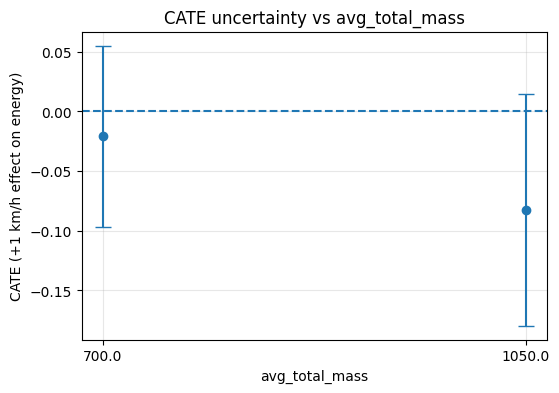

In [ ]:
cate_uncertainty_mass_two_groups(linear_dml, df)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from econml.dml import LinearDML

def placebo_cate_refutation(
    base_linear_dml,
    df,
    Y_col="total_energy_consumption",
    T_col="avg_vehicle_speed",
    X_cols=("avg_slope", "avg_total_mass", "avg_outdoor_temp"),
    n_bins=30,
    seed=42
):
    rng = np.random.RandomState(seed)

    Y = df[Y_col].values
    T = df[T_col].values
    X = df[list(X_cols)].values

    real_model = LinearDML(
        model_y=base_linear_dml.model_y,
        model_t=base_linear_dml.model_t,
        featurizer=base_linear_dml.featurizer,
        random_state=base_linear_dml.random_state
    )
    real_model.fit(Y=Y, T=T, X=X)
    cate_real = real_model.effect(X).ravel()


    T_shuffled = rng.permutation(T)

    placebo_model = LinearDML(
        model_y=base_linear_dml.model_y,
        model_t=base_linear_dml.model_t,
        featurizer=base_linear_dml.featurizer,
        random_state=base_linear_dml.random_state
    )
    placebo_model.fit(Y=Y, T=T_shuffled, X=X)
    cate_placebo = placebo_model.effect(X).ravel()

    plt.figure(figsize=(8,5))
    plt.hist(cate_real, bins=n_bins, alpha=0.5, density=True, label="Real CATE")
    plt.hist(cate_placebo, bins=n_bins, alpha=0.5, density=True, label="Placebo CATE (T shuffled)")
    plt.axvline(0, linestyle="--")
    plt.xlabel("CATE (+1 km/h)")
    plt.ylabel("Density")
    plt.title("Placebo CATE Refutation (Heterogeneity Check)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("Real CATE mean:", np.mean(cate_real))
    print("Placebo CATE mean:", np.mean(cate_placebo))
    print("Real CATE std:", np.std(cate_real))
    print("Placebo CATE std:", np.std(cate_placebo))

    return cate_real, cate_placebo

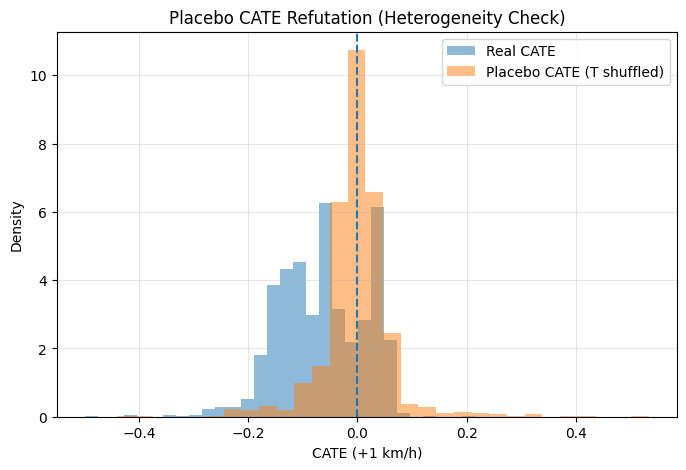

Real CATE mean: -0.06354184897271532
Placebo CATE mean: -0.00037810418276176263
Real CATE std: 0.0798085153970154
Placebo CATE std: 0.06507120594608003


In [ ]:
cate_real, cate_placebo = placebo_cate_refutation(
    base_linear_dml=linear_dml,
    df=df
)


Energy Consumption to Range Estimation using ATE:

In [ ]:
ate = r_ate
ate

np.float64(-0.05258017812479709)

In [ ]:
battery_capacity = 15600
SoC_min = 5
distance = 0.05

In [ ]:
E = df['total_energy_consumption'].values
SoC_start = df['SoC_start'].values

In [ ]:
E_mean = np.mean(E)
SoC_start_mean = np.mean(SoC_start)

print(E_mean)
print(SoC_start_mean)

5.15821044053984
54.456007345269114


In [ ]:
E1_mean = E_mean + ate

In [ ]:
def define_range(E, SoC_start):
    SoC_diff = (E / battery_capacity) * 100
    SoC_est = SoC_start - SoC_diff

    E_usable = battery_capacity * ((SoC_est - SoC_min) / 100)
    E_usable = np.maximum(E_usable, 0)

    E_per_km = np.abs(E) / distance

    E_min = 0.05
    E_avg = np.maximum(E_per_km, E_min)

    R = E_usable / E_avg
    return np.maximum(R, 0)

In [ ]:
R0 = define_range(E_mean, SoC_start_mean)
R1 = define_range(E1_mean, SoC_start_mean)

In [ ]:
ate_range = R1 - R0

print("R0:", R0)
print("R1:", R1)
print("ATE (Range):", ate_range)

R0: 74.73501735046062
R1: 75.50518857932931
ATE (Range): 0.7701712288686906


Energy Consumption to Range Estimation using CATE:

In [ ]:
battery_capacity = 15600
SoC_min = 5
distance = 0.05

In [ ]:
def define_range(E, SoC_start):
    SoC_diff = (E / battery_capacity) * 100
    SoC_est = SoC_start - SoC_diff

    E_usable = battery_capacity * ((SoC_est - SoC_min) / 100)
    E_usable = np.maximum(E_usable, 0)

    E_per_km = np.abs(E) / distance

    E_min = 0.05
    E_avg = np.maximum(E_per_km, E_min)

    R = E_usable / E_avg
    return np.maximum(R, 0)

In [ ]:
i = 0

E0 = df['total_energy_consumption'].iloc[i]
SoC_start0 = df['SoC_start'].iloc[i]

slope = df['avg_slope'].iloc[i]
mass = df['avg_total_mass'].iloc[i]
outdoor_temp = df['avg_outdoor_temp'].iloc[i]

In [ ]:
X_input = np.array([[slope, mass, outdoor_temp]])

cate_ldml = linear_dml.effect(X_input)[0]

lower, upper = linear_dml.effect_interval(X_input)
ci_lower = lower[0]
ci_upper = upper[0]

print("CATE (Energy):", cate_ldml)
print("CI Lower:", ci_lower)
print("CI Upper:", ci_upper)

CATE (Energy): -0.025378908693585167
CI Lower: -0.12591549990783396
CI Upper: 0.07515768252066359


In [ ]:
R0 = define_range(E0, SoC_start0)

In [ ]:
E1 = E0 + cate_ldml

In [ ]:
R1 = define_range(E1, SoC_start0)

In [ ]:
cate_range = R1 - R0

In [ ]:
R1_low = define_range(E0 + ci_lower, SoC_start0)
R1_high = define_range(E0 + ci_upper, SoC_start0)

ci_range = (R1_low - R0, R1_high - R0)
ci_range = (min(ci_range), max(ci_range))

print("CATE (Range):", cate_range)
print("CI Range effect (km):", ci_range)

CATE (Range): 0.04483580490403227
CI Range effect (km): (np.float64(-0.13192617748666535), np.float64(0.22389466594568574))
